In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters 

Lx = 6
Ly = 3
K = 2 
J = 1 
W = 4 

N = Lx * Ly 

print ("Total number of sites =", N)

# Create random connection matrices T 

def random_T(Ly, K):

    while True:

        Tx = np.zeros((Ly, Ly), dtype=int)

        for j in range(Ly):

            rows = np.random.choice(Ly, K, replace=False)

            for i in rows:
                Tx[i, j] = 1


        row_sum = Tx.sum(axis=1)
        col_sum = Tx.sum(axis=0)

        if np.all(row_sum == K) and np.all(col_sum == K):

            return Tx

np.random.seed(0)

T = []

for x in range(Lx - 1):

    Tx = random_T(Ly, K)
    T.append(Tx)

    print(f"\nConnection matrix T({x+1}, {x+2}):")

    print(Tx)

    print("Row sums:", Tx.sum(axis=1))
    print("Column sums:", Tx.sum(axis=0))


Total number of sites = 18

Connection matrix T(1, 2):
[[1 0 1]
 [0 1 1]
 [1 1 0]]
Row sums: [2 2 2]
Column sums: [2 2 2]

Connection matrix T(2, 3):
[[1 1 0]
 [0 1 1]
 [1 0 1]]
Row sums: [2 2 2]
Column sums: [2 2 2]

Connection matrix T(3, 4):
[[1 0 1]
 [0 1 1]
 [1 1 0]]
Row sums: [2 2 2]
Column sums: [2 2 2]

Connection matrix T(4, 5):
[[1 0 1]
 [1 1 0]
 [0 1 1]]
Row sums: [2 2 2]
Column sums: [2 2 2]

Connection matrix T(5, 6):
[[1 0 1]
 [0 1 1]
 [1 1 0]]
Row sums: [2 2 2]
Column sums: [2 2 2]


In [16]:

# Create random onsite potentials
np.random.seed(0)

epsilon = np.random.uniform(-W/2, W/2, size=(Lx, Ly))

print("\nOnsite potential epsilon:")
print(epsilon)


Onsite potential epsilon:
[[ 0.19525402  0.86075747  0.4110535 ]
 [ 0.17953273 -0.3053808   0.58357645]
 [-0.24965115  1.567092    1.85465104]
 [-0.46623392  1.16690015  0.11557968]
 [ 0.27217824  1.70238655 -1.71585577]
 [-1.6514828  -1.91912641  1.33047938]]


# Create the Hamiltonian

In [17]:
H = np.zeros((N, N))

# Put onsite potentails on the diagonal 

for x in range(Lx):
    for y in range(Ly):

        site = x * Ly + y 

        H[site, site] = epsilon[x, y]    # Take the onsite potential belonging to the physical site (x,y), and put it on the corresponding diagonal element of the Hamiltonian.
        


In [18]:
# Put the hopping terms between neighboring layers 

for x in range(Lx - 1):

    Tx = T[x]

    for i in range(Ly):
        for j in range(Ly):

            if Tx[i, j] == 1:

                site1 = x * Ly + j     # Site j in layer x

                site2 = (x + 1) * Ly + i    # Site i in layer x+1 

                H[site1, site2] = J 
                H[site2, site1] = J 



In [19]:
print ("\nHamiltonian H:")
print(H)



Hamiltonian H:
[[ 0.19525402  0.          0.          1.          0.          1.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.86075747  0.          0.          1.          1.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.4110535   1.          1.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 1.          0.          1.          0.17953273  0.          0.
   1.          0.          1.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          1.          1.          0.         -0.3053808   0.
   1.          1.          0.          0.          0.          0.
   0.          0.       

In [20]:
print("\nIs H Hermitian?")
print(np.allclose(H, H.T))


Is H Hermitian?
True


# Plot the Hamiltonian 

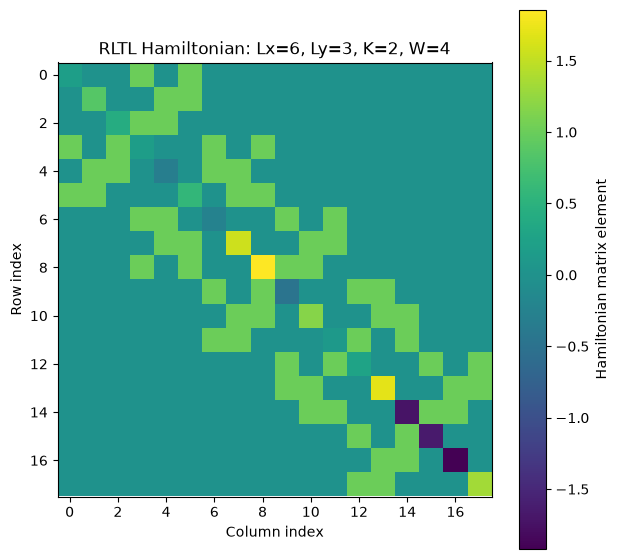

In [21]:
plt.figure(figsize=(7, 7))

plt.imshow(H, interpolation="None")

plt.colorbar(label="Hamiltonian matrix element")

plt.xlabel("Column index")
plt.ylabel("Row index")

plt.title(f"RLTL Hamiltonian: Lx={Lx}, Ly={Ly}, K={K}, W={W}")
plt.show()


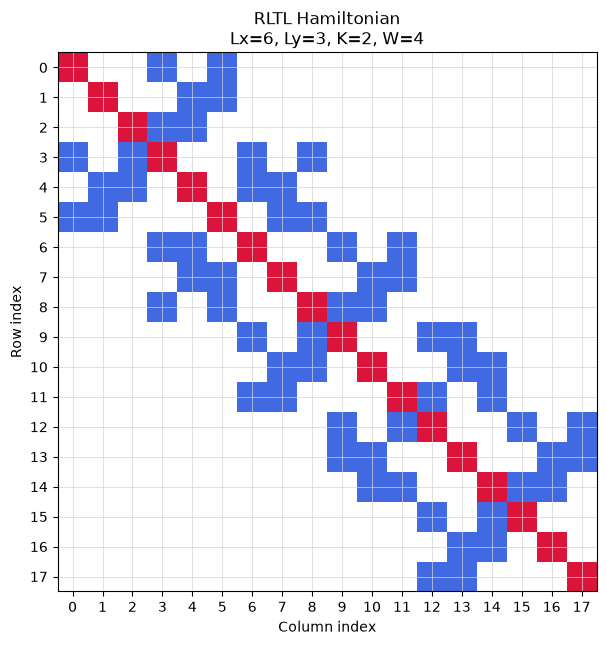

In [22]:
from matplotlib.colors import ListedColormap

plot_matrix = np.zeros((N, N), dtype=int)

for i in range(N):
    for j in range(N):

        if i != j and H[i, j] == J:

            plot_matrix[i, j] = 1 


for i in range(N):

    if H[i, i] != 0:

        plot_matrix[i, i] = 2

cmap = ListedColormap(["white", "royalblue", "crimson"])

plt.figure (figsize=(7, 7))

plt.imshow(plot_matrix, cmap=cmap, interpolation="none")

plt.xlabel("Column index")
plt.ylabel("Row index")

plt.title(
    f"RLTL Hamiltonian\n"
    f"Lx={Lx}, Ly={Ly}, K={K}, W={W}"
)

plt.xticks(np.arange(N))
plt.yticks(np.arange(N))

plt.grid(
    True,
    color="lightgray",
    linewidth=0.5
)

plt.show()
